<a href="https://colab.research.google.com/github/Pameta1/TelecomX_2/blob/main/TelecomX_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [59]:
import pandas as pd

In [60]:
import warnings
warnings.filterwarnings('ignore')

In [61]:
datos_cliente = pd.read_csv('/content/datos_tratados.csv')

In [62]:
datos_cliente.head(2)

,CustomerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_bin,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,0.0,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,0.0,1.996667


#### Eliminación de Columnas

In [63]:
columnas_a_eliminar = ['CustomerID', 'Churn']

In [64]:
datos_cliente = datos_cliente.drop(columns=['CustomerID', 'Churn'])

In [65]:
datos_cliente.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn_bin,Cuentas_Diarias
0,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,...,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3,0.0,2.186667
1,Male,0,No,No,9,Yes,Yes,DSL,No,No,...,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4,0.0,1.996667


##### Gestión de limpieza de datos numéricos

In [66]:
cols_num = ['MonthlyCharges', 'TotalCharges', 'Cuentas_Diarias', 'Churn_bin']

for col in cols_num:
    datos_cliente[col] = (
        datos_cliente[col]
        .astype(str)      # asegurar que es string
        .str.strip()      # eliminar espacios
        .replace('', None)  # convertir vacío en NaN real
    )

In [67]:
for col in cols_num:
    datos_cliente[col] = pd.to_numeric(datos_cliente[col], errors='coerce')

In [68]:
for col in cols_num:
    try:
        datos_cliente[col].astype(float)
        print(f"{col} OK")
    except:
        print(f"{col} tiene problema")

MonthlyCharges OK
TotalCharges OK
Cuentas_Diarias OK
Churn_bin OK


In [69]:
datos_cliente_corr = datos_cliente[cols_num].dropna()
datos_cliente_corr.corr()

,MonthlyCharges,TotalCharges,Cuentas_Diarias,Churn_bin
MonthlyCharges,1.000000,0.651065,1.000000,0.192858
TotalCharges,0.651065,1.000000,0.651065,-0.199484
Cuentas_Diarias,1.000000,0.651065,1.000000,0.192858
Churn_bin,0.192858,-0.199484,0.192858,1.000000


In [70]:
datos_cliente['Churn_bin'].isna().sum()

np.int64(224)

In [71]:
datos_cliente = datos_cliente.dropna(subset=['Churn_bin'])

In [72]:
# Separar X e y
X = datos_cliente.drop('Churn_bin', axis=1)
y = datos_cliente['Churn_bin']

In [73]:
# Separar variables predictoras y objetivo
X = datos_cliente.drop('Churn_bin', axis=1)
y = datos_cliente['Churn_bin']

Se identificaron 11 valores faltantes en la variable TotalCharges, asociados a clientes con antigüedad (tenure) igual a cero. Debido a que representan una proporción mínima del dataset, estos registros fueron eliminados para evitar inconsistencias durante el entrenamiento de los modelos.

In [74]:
datos_cliente = datos_cliente.dropna(subset=['TotalCharges'])

In [75]:
X = datos_cliente.drop('Churn_bin', axis=1)
y = datos_cliente['Churn_bin']

In [76]:
X_encoded = pd.get_dummies(X, drop_first=True)

In [77]:
print("NaN en X:", X_encoded.isna().sum().sum())
print("NaN en y:", y.isna().sum())

NaN en X: 0
NaN en y: 0


In [78]:
# Dividir train-test

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3, random_state=42, stratify=y)

In [79]:
 # Pipeline de preprocesamiento
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Identificar columnas
columnas_numericas = X.select_dtypes(include=['int64','float64']).columns
columnas_categoricas = X.select_dtypes(include=['object']).columns

preprocesador = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), columnas_numericas),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), columnas_categoricas)
    ]
)

In [80]:
# Aplicar One_Hot Encoding
X_encoded = pd.get_dummies(X,drop_first=True)

print(X_encoded.shape)

(7032, 31)


In [81]:
X.select_dtypes(include=['object']).columns

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')

In [82]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline_log = Pipeline(steps=[
    ('preprocesamiento', preprocesador),
    ('modelo', LogisticRegression(max_iter=1000))
])

pipeline_log.fit(X_train, y_train)

Pipeline(steps=[('preprocesamiento',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'Cuentas_Diarias'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object'))])),
                ('modelo', LogisticRegression(max_iter=1000))])

## Verificación de la proporción de cancelación (Churn)

Primeo calculamos cuántos clientes cancelaron y los que  no cancelaron

In [83]:
datos_cliente['Churn_bin'].value_counts()

,count
Churn_bin,
0.0,5163
1.0,1869




*   0 = cliente activo
*   1 = cliente canceló



####Proporción (porcentaje)

In [84]:
(datos_cliente['Churn_bin'].value_counts(normalize=True) * 100).round(2)

,proportion
Churn_bin,
0.0,73.42
1.0,26.58


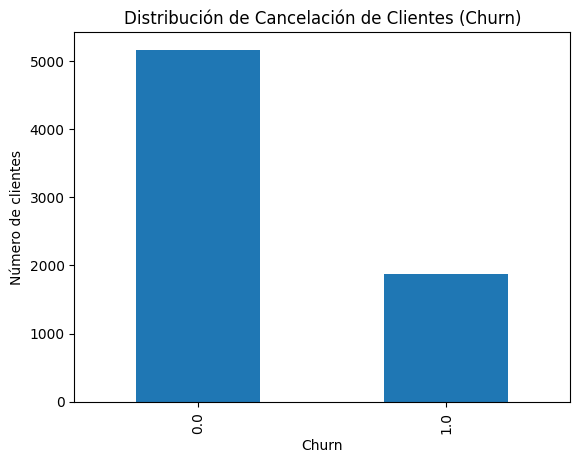

In [85]:
import matplotlib.pyplot as plt

datos_cliente['Churn_bin'].value_counts().plot(
    kind='bar',
    title='Distribución de Cancelación de Clientes (Churn)',
)

plt.xlabel('Churn')
plt.ylabel('Número de clientes')
plt.show()

##Interpretación

El análisis de la variable objetivo muestra que aproximadamente 73% de los clientes permanecen activos, mientras que cerca del 27% han cancelado el servicio.
Esto indica un desbalance moderado entre las clases, lo cual es común en problemas de churn y debe considerarse al evaluar el desempeño de los modelos predictivos.

####Balanceo de Clases Técnica SMOTE

In [86]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_bal, y_bal = smote.fit_resample(X_encoded, y)

In [87]:
y_bal.value_counts()

,count
Churn_bin,
0.0,5163
1.0,5163


Debido al desbalance existente entre clientes que cancelan y aquellos que permanecen activos, se aplicó la técnica SMOTE (Synthetic Minority Over-sampling Technique) para generar ejemplos sintéticos de la clase minoritaria. Esto permite entrenar modelos más equilibrados y mejorar la capacidad de detectar clientes con riesgo de cancelación.

##Normalización /estandarización

####Aplicar estandireación con StandarScaler

In [88]:
# Identificación de variables numéricas
from sklearn.preprocessing import StandardScaler

columnas_numericas = ['tenure','MonthlyCharges','TotalCharges','Cuentas_Diarias']

In [89]:
scaler = StandardScaler()

X_encoded[columnas_numericas] = scaler.fit_transform(X_encoded[columnas_numericas])

In [90]:
X_encoded[columnas_numericas].describe()

,tenure,MonthlyCharges,TotalCharges,Cuentas_Diarias
count,7.032000e+03,7.032000e+03,7.032000e+03,7.032000e+03
mean,-1.111486e-16,5.860563e-17,8.285623e-17,7.729880e-17
std,1.000071e+00,1.000071e+00,1.000071e+00,1.000071e+00
min,-1.280248e+00,-1.547283e+00,-9.990692e-01,-1.547283e+00
25%,-9.542963e-01,-9.709769e-01,-8.302488e-01,-9.709769e-01
50%,-1.394171e-01,1.845440e-01,-3.908151e-01,1.845440e-01
75%,9.199259e-01,8.331482e-01,6.668271e-01,8.331482e-01
max,1.612573e+00,1.793381e+00,2.824261e+00,1.793381e+00


Se aplicó estandarización mediante StandardScaler a las variables numéricas para garantizar que todas tengan media cero y desviación estándar uno. Este paso es necesario para modelos sensibles a la escala de los datos, como Regresión Logística, evitando que variables con magnitudes mayores influyan desproporcionadamente en el modelo.

##Correlación y Selección de Variables

Seleccionar sólo variables numéricas

In [91]:
variables_numericas = datos_cliente.select_dtypes(include=['int64','float64'])

variables_numericas.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_bin,Cuentas_Diarias
0,0,9,65.6,593.30,0.0,2.186667
1,0,9,59.9,542.40,0.0,1.996667
2,0,4,73.9,280.85,1.0,2.463333
3,1,13,98.0,1237.85,1.0,3.266667
4,1,3,83.9,267.40,1.0,2.796667


####Calcular matriz de correlación

Esto calcula la correlación de Pearson entre todas las variables numéricas:

Estos van de valor 1 correlación positiva perfecta.

valor 0 hay correlación

valor -1 correlación negativa perfecta

In [92]:
matriz_corr = variables_numericas.corr()
matriz_corr

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn_bin,Cuentas_Diarias
SeniorCitizen,1.000000,0.015683,0.219874,0.102411,0.150541,0.219874
tenure,0.015683,1.000000,0.246862,0.825880,-0.354049,0.246862
MonthlyCharges,0.219874,0.246862,1.000000,0.651065,0.192858,1.000000
TotalCharges,0.102411,0.825880,0.651065,1.000000,-0.199484,0.651065
Churn_bin,0.150541,-0.354049,0.192858,-0.199484,1.000000,0.192858
Cuentas_Diarias,0.219874,0.246862,1.000000,0.651065,0.192858,1.000000


#### Visualizar matriz con Heatman

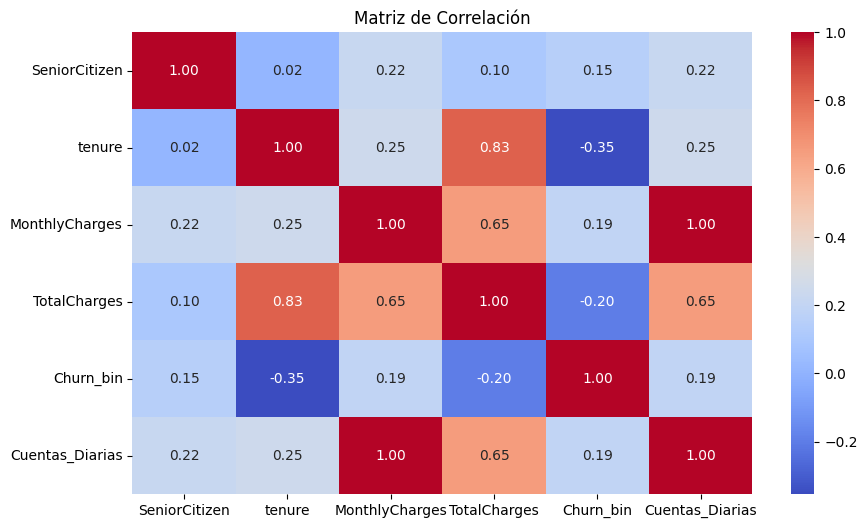

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.heatmap(
    matriz_corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlación")
plt.show()

###Correlación específica con Churn

In [94]:
matriz_corr['Churn_bin'].sort_values(ascending=False)

,Churn_bin
Churn_bin,1.000000
Cuentas_Diarias,0.192858
MonthlyCharges,0.192858
SeniorCitizen,0.150541
TotalCharges,-0.199484
tenure,-0.354049


###Interpretación típica en churn

Variable         Interpretación

**tenure ** Clientes nuevos cancelan más

**MonthlyCharges**  Cargos altos aumentan churn.

**TotalCharges **  Clientes antiguos suelen quedarse.

**Cuentas_Diarias**  Puede indicar uso intensivo.

###Identificación de variables importantes
variables con mayor correlación absoluta con Chur_bin son buenas candidatas para el modelo

In [95]:
corr_churn = matriz_corr['Churn_bin'].abs().sort_values(ascending=False)

corr_churn

,Churn_bin
Churn_bin,1.000000
tenure,0.354049
TotalCharges,0.199484
Cuentas_Diarias,0.192858
MonthlyCharges,0.192858
SeniorCitizen,0.150541


In [96]:
corr_churn[1:10]  #Se quita la correlación consigo mismo

,Churn_bin
tenure,0.354049
TotalCharges,0.199484
Cuentas_Diarias,0.192858
MonthlyCharges,0.192858
SeniorCitizen,0.150541


##Interpretación
Se analizó la matriz de correlación entre las variables numéricas del dataset. Se observó que variables como tenure, MonthlyCharges y TotalCharges presentan una relación relevante con la cancelación de clientes. En particular, la variable tenure muestra una correlación negativa con el churn, indicando que los clientes con mayor antigüedad tienden a cancelar menos sus servicios.

##Análisis Dirigido

####Tiempo de contrato (tenure) vs Cancelación

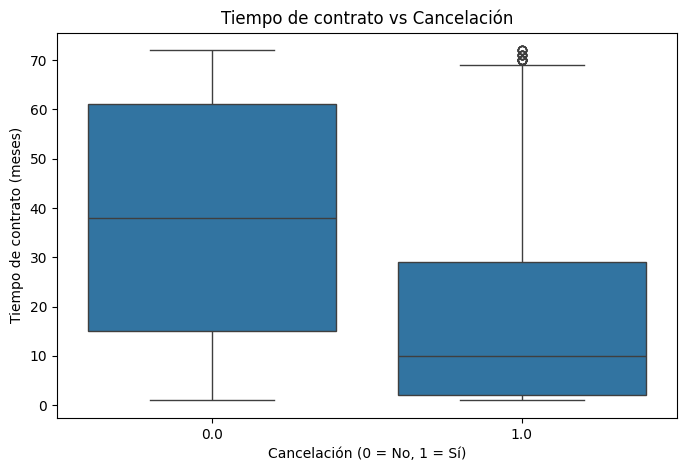

In [97]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn_bin',
    y='tenure',
    data=datos_cliente
)

plt.title('Tiempo de contrato vs Cancelación')
plt.xlabel('Cancelación (0 = No, 1 = Sí)')
plt.ylabel('Tiempo de contrato (meses)')

plt.show()

se observa:

1.   Clientes que han gastado más dinero  tienden a quedarse
2.   Clientes con bajo gasto total cancelan con mayor frecuencia

Esto suele estar relacionado con la antigüedad del cliente, factor importante en la retención

####Gasto total (TotalCharges) vs Cancelación

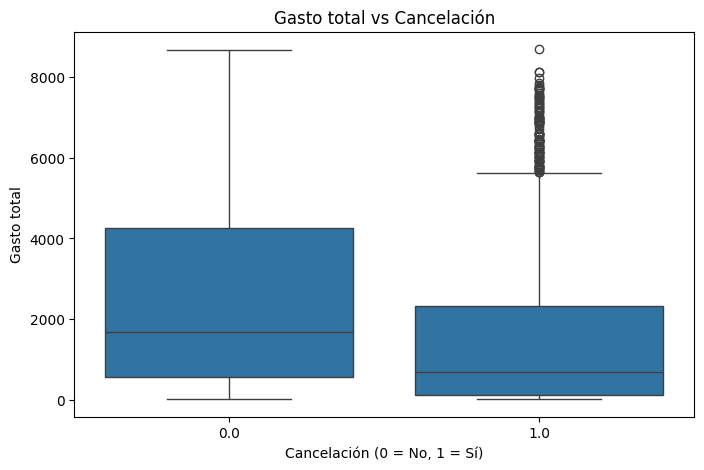

In [98]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn_bin',
    y='TotalCharges',
    data=datos_cliente
)

plt.title('Gasto total vs Cancelación')
plt.xlabel('Cancelación (0 = No, 1 = Sí)')
plt.ylabel('Gasto total')

plt.show()

Se observa;

-Clientes que han gastado más dinero
tienden a quedarse

-Clientes con bajo gasto total cancelan con mayor frecuencia

Esto suele estar relacionado con la antigüedad del cliente


##Alternativa: Scatter Plot (opcional)

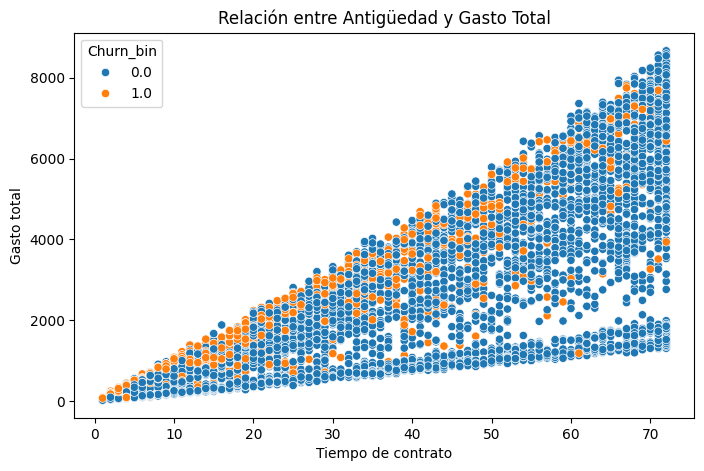

In [99]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x='tenure',
    y='TotalCharges',
    hue='Churn_bin',
    data=datos_cliente
)

plt.title('Relación entre Antigüedad y Gasto Total')
plt.xlabel('Tiempo de contrato')
plt.ylabel('Gasto total')

plt.show()

**Este gráfico permite ver cómo se agrupan los clientes que cancelan vs los que no.**

##Interpretación

El análisis visual muestra que los clientes con menor antigüedad (tenure) presentan mayor probabilidad de cancelar el servicio. Asimismo, los clientes con menor gasto total acumulado tienden a abandonar con mayor frecuencia. Estos resultados sugieren que los clientes nuevos representan un grupo de mayor riesgo de cancelación.



###Separación de Datos (Train / Test)

Entrenamiento (Train) → el modelo aprende patrones.

Prueba (Test) → evaluamos qué tan bien predice.

La división más común es:
70% entrenamiento
30% prueba

In [100]:
from sklearn.model_selection import train_test_split

####Definir variables predictoras y variable objetivo
Recordemos:

-  X → variables que explican el churn

-  y → variable objetivo (Churn_bin)

In [101]:
X = X_encoded
y = datos_cliente['Churn_bin']

#####Dividir el dataset

In [102]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

####Qué significa cada parámetro

Parámetro

**test_size=0.30**
30% de datos para prueba

**random_state=42**
asegura resultados reproducibles

**stratify=y**
mantiene la proporción de churn
Esto es muy importante en problemas con desbalance de clases.

In [103]:
print("Tamaño entrenamiento:", X_train.shape)
print("Tamaño prueba:", X_test.shape)

Tamaño entrenamiento: (4922, 31)
Tamaño prueba: (2110, 31)


####Verificar proporción de churn
Esto confirma que **stratify** funcionó

In [104]:
print("Train:")
print(y_train.value_counts(normalize=True))

print("\nTest:")
print(y_test.value_counts(normalize=True))

Train:
Churn_bin
0.0    0.734254
1.0    0.265746
Name: proportion, dtype: float64

Test:
Churn_bin
0.0    0.734123
1.0    0.265877
Name: proportion, dtype: float64


#####Interpretación
El conjunto de datos fue dividido en 70% para entrenamiento y 30% para prueba utilizando la función **train_test_split** de Scikit-learn. Se utilizó el parámetro stratify para mantener la proporción de clientes que cancelan y los que permanecen activos en ambos subconjuntos, garantizando una evaluación más representativa del modelo.

##Creación Modelos Predictivos

###**Modelo 1: Regresión Logística**
Este modelo es uno de los más usados para problemas de clasificación binaria como churn.

In [105]:
from sklearn.linear_model import LogisticRegression

modelo_logistico = LogisticRegression(max_iter=1000)

modelo_logistico.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

####Predicciones con Regresión Logística

Ahora se usa los datos de prueba

In [106]:
y_pred_log = modelo_logistico.predict(X_test)
y_pred_log

array([0., 0., 0., ..., 0., 0., 0.])

######Evaluación del Modelo

In [107]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_log))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_log))

Accuracy: 0.8028436018957346

Matriz de Confusión:
[[1391  158]
 [ 258  303]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1549
         1.0       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



#### **Modelo 2: Random Forest**

Random Forest es un modelo basado en múltiples árboles de decisión.

In [108]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

modelo_rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

###Predicciones con Random Forest

In [109]:
y_pred_rf = modelo_rf.predict(X_test)

####Evaluación del modelo

In [110]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7853080568720379

Matriz de Confusión:
[[1390  159]
 [ 294  267]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1549
         1.0       0.63      0.48      0.54       561

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.77      0.79      0.78      2110



####Interpretación

Se implementaron dos modelos de clasificación para predecir la cancelación de clientes. El primero fue Regresión Logística, un modelo lineal que requiere normalización de los datos para evitar que variables con mayor magnitud dominen el proceso de optimización. El segundo modelo fue Random Forest, un algoritmo basado en árboles de decisión que no depende de la escala de las variables, lo que permite trabajar directamente con los datos sin necesidad de normalización.

##Evaluación de los Modelos

In [111]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

######**Evaluación del modelo Regresión Logística**

In [112]:
print("Evaluación - Regresión Logística")

print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1-score:", f1_score(y_test, y_pred_log))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_log))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_log))

Evaluación - Regresión Logística
Accuracy: 0.8028436018957346
Precision: 0.6572668112798264
Recall: 0.5401069518716578
F1-score: 0.5929549902152642

Matriz de Confusión:
[[1391  158]
 [ 258  303]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.84      0.90      0.87      1549
         1.0       0.66      0.54      0.59       561

    accuracy                           0.80      2110
   macro avg       0.75      0.72      0.73      2110
weighted avg       0.79      0.80      0.80      2110



#####**Evaluación del modelo Random Forest**

In [113]:
print("Evaluación - Random Forest")

print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1-score:", f1_score(y_test, y_pred_rf))

print("\nMatriz de Confusión:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_rf))

Evaluación - Random Forest
Accuracy: 0.7853080568720379
Precision: 0.6267605633802817
Recall: 0.47593582887700536
F1-score: 0.541033434650456

Matriz de Confusión:
[[1390  159]
 [ 294  267]]

Reporte de Clasificación:
              precision    recall  f1-score   support

         0.0       0.83      0.90      0.86      1549
         1.0       0.63      0.48      0.54       561

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.77      0.79      0.78      2110



####Significado

###**Métrica**    
-**Accuracy**
porcentaje de predicciones correctas

**Precision**
de los clientes que el modelo predijo que cancelan, cuántos realmente cancelan

-**Recall**
cuántos clientes que cancelaron fueron detectados por el modelo

-**F1-score**
balance entre precision y recall

En churn Recall suele ser muy importante, porque queremos detectar clientes en riesgo de irse.

####Interpretar la Matriz de Confusión

[[1390  159]

 [ 294  267]]

 **1390**
  Clientes correctamente     clasificados como activos

  **267**
  Clientes correctamente detectados como churn

  **159**
  falsos positivos

  **294**
  falsos negativos
Los falsos negativos son importantes en churn porque significan:

⚠️ clientes que cancelaron pero el modelo no detectó.

####Análisis crítico (parte importante del desafío)
Ejemplo de interpretación:

Comparación de desempeño

Al comparar ambos modelos, se observa que **Regresión Logística** presenta un mejor desempeño general, mostrando valores superiores en métricas como F1-score y recall. Esto indica que el modelo logra identificar con mayor precisión a los clientes con riesgo de cancelación.

###Detectar Overfitting o Underfitting

 **Overfitting**

Se sospecha cuando:

-Accuracy entrenamiento muy alto

-Accuracy prueba mucho menor

El modelo memoriza datos.
Causas:
modelo demasiado complejo
demasiados árboles
pocos datos

**Underfitting**

El modelo no captura patrones.
Causas:
modelo demasiado simple
pocas variables
parámetros mal ajustados

##Interpretación: Importancia de las variables
1️** Importancia en Random Forest**

Random Forest permite ver qué variables influyen más en la cancelación (Churn)

In [114]:
# Obtener importancia de variables
importancias = modelo_rf.feature_importances_

# Crear dataframe
df_importancia = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': importancias
})

# Ordenar
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

print(df_importancia.head(10))

                          Variable  Importancia
3                     TotalCharges     0.167968
1                           tenure     0.152785
2                   MonthlyCharges     0.129486
4                  Cuentas_Diarias     0.128438
29  PaymentMethod_Electronic check     0.039787
11     InternetService_Fiber optic     0.036134
26               Contract_Two year     0.031948
5                      gender_Male     0.024826
27            PaperlessBilling_Yes     0.023676
20                 TechSupport_Yes     0.021171


##Gráfico de importancia

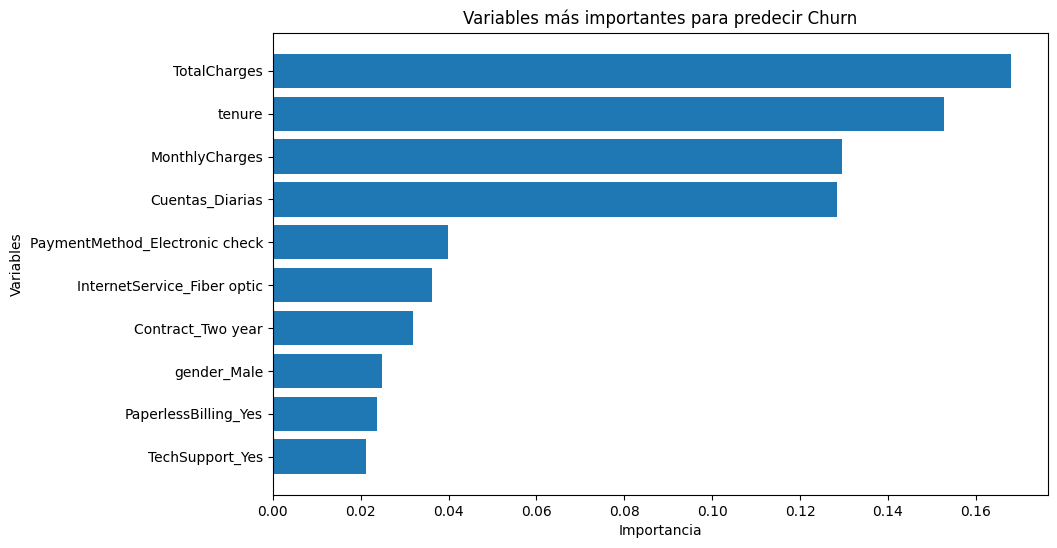

In [115]:
import pandas as pd
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.barh(df_importancia['Variable'][:10], df_importancia['Importancia'][:10])

plt.xlabel("Importancia")
plt.ylabel("Variables")
plt.title("Variables más importantes para predecir Churn")

plt.gca().invert_yaxis()

plt.show()

##Interpretación en Regresión Logística
La regresión logística usa coeficientes.

In [116]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train, y_train)


coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': modelo_lr.coef_[0]
})

coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)

print(coeficientes.head(10))

                          Variable  Coeficiente
11     InternetService_Fiber optic     0.959735
3                     TotalCharges     0.636394
29  PaymentMethod_Electronic check     0.391511
27            PaperlessBilling_Yes     0.367623
22                 StreamingTV_Yes     0.319852
0                    SeniorCitizen     0.259168
24             StreamingMovies_Yes     0.226484
10               MultipleLines_Yes     0.214625
18            DeviceProtection_Yes     0.030941
30      PaymentMethod_Mailed check     0.016689
